# 245: Where the P66 and CD47 shared k-mers sit, and whether they touch the SIRP-alpha residues

Notebook 241 counted how many k-mers P66 and CD47 share in each arm of its sweep (one
alphabet at one k-mer size) and recorded the count in `pair_P66_shared_kmers`. It never
recorded where those k-mers sit, so one question stayed open: does a shared k-mer land on
the part of P66 that matters, and on the part of CD47 that binds SIRP-alpha?

**P66** is a surface protein of *Borreliella burgdorferi* (UniProt H7C7N8). A seven-residue
loop of it is required for binding human integrins, and the same loop has been proposed to
bind SIRP-alpha, the receptor CD47 binds. The integrin result is measured. The SIRP-alpha
binding is a proposal, so this notebook calls the stretch "the loop required for integrin
binding, proposed to bind SIRP-alpha" and never "the SIRP-alpha-binding region of P66".

**CD47** (UniProt Q08722) is the human protein whose extracellular domain binds SIRP-alpha.
Nine of its residues contact SIRP-alpha; seven of them lie in one stretch.

## Two numbering systems

Mixing them is the main way to get a wrong answer here, so every table and every axis in
this notebook carries both.

| | UniProt entry | signal peptide | mature chain | conversion |
|---|---|---|---|---|
| P66 | H7C7N8, 618 aa | 1-21 | 22-618, 597 aa | mature = UniProt - 21 |
| CD47 | Q08722, 323 aa | 1-18 | 19-323, 305 aa | mature = UniProt - 18 |

The published positions are in mature numbering in both papers:

* P66's loop, mature 181-187 with aspartate at 184 and 186, is **UniProt 202-208**,
  sequence QENDKDT, with aspartate at UniProt 205 and 207.
* CD47's contact residues Tyr37, Asp46, Glu97, Thr99, Glu100, Thr102, Arg103, Glu104,
  Glu106 are **UniProt 55, 64, 115, 117, 118, 120, 121, 122, 124**. Seven of the nine lie
  in UniProt 115-124.

`scripts/fetch_p66_cd47_annotations.py` fetches both entries from UniProt, checks the
lengths (618 and 323) and checks the residue at each named position against the residue the
name says. It stops with an error if any of them disagrees.

Notebook 241 ran P66 as its 597-residue mature chain and CD47 as the 323-residue GENCODE
protein, which is the UniProt precursor. So kmerseek's P66 positions are mature numbering
and its CD47 positions are UniProt numbering. `245_p66_cd47_pair_runs.py` checks both
sequences against the UniProt entries before it writes a coordinate.

## What was run

Every arm of the notebook 241 sweep whose `pair_P66_shared_kmers` is above zero, re-run
with `kmerseek pair` keeping the per-k-mer output. Then two controls:

1. **Position.** A k-mer has to land somewhere. For each arm, the share of the places a
   k-mer of that length can sit from which it would touch the named stretch, against how
   many actually do, with a binomial test.
2. **Partner.** The same arms run on P66 against the 300 length-matched human proteins
   PR #44 drew (`analysis/ranking-metrics-p66/random_ladder.csv`, 242 to 404 residues,
   median 322.5 against CD47's 323), to see where CD47's count sits among them.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import p66_cd47_coordinate_utils as pc

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(60)

data = pc.load()
ann, kmers, regions = data["annotations"], data["kmers"], data["regions"]
controls, control_counts = data["controls"], data["control_counts"]

n_arms = controls.height
n_alphabets = kmers["alphabet"].n_unique()
n_kmers = kmers.height
n_regions = regions.height
print(f"{n_arms} arms over {n_alphabets} alphabets; "
      f"{n_kmers} shared k-mers; {n_regions} chained regions")
print(ann.filter(pl.col("feature_type") == "PUBLISHED")
      .select("protein", "name", "start_uniprot", "end_uniprot",
              "start_mature", "end_mature", "sequence", "source"))

27 arms over 16 alphabets; 326 shared k-mers; 213 chained regions
shape: (12, 8)
┌─────────┬──────────────────────────────────────────────────────┬───────────────┬─────────────┬──────────────┬────────────┬──────────┬────────────────────────────────────────────────────────────────┐
│ protein ┆ name                                                 ┆ start_uniprot ┆ end_uniprot ┆ start_mature ┆ end_mature ┆ sequence ┆ source                                                         │
│ ---     ┆ ---                                                  ┆ ---           ┆ ---         ┆ ---          ┆ ---        ┆ ---      ┆ ---                                                            │
│ str     ┆ str                                                  ┆ i64           ┆ i64         ┆ i64          ┆ i64        ┆ str      ┆ str                                                            │
╞═════════╪══════════════════════════════════════════════════════╪═══════════════╪═════════════╪══════════════╪════

## 1. Where the shared k-mers sit

One line per shared k-mer, from its place on P66 to its place on CD47. Both proteins are
drawn the way InterPro draws a protein: a thin line for the chain with open boxes for the
UniProt features. The two stretches named in the literature are grey boxes with a black
outline, and no alphabet uses grey or black. A k-mer that touches one of them is drawn
thicker with a square at each end, so it can be found without reading its colour.

In [2]:
touch_loop = int(kmers["overlaps_p66_loop"].sum())
touch_contact = int(kmers["overlaps_cd47_contact_span"].sum())
reg_loop = int(regions["overlaps_p66_loop"].sum())
reg_contact = int(regions["overlaps_cd47_contact_span"].sum())
all_seven = kmers.filter(pl.col("n_cd47_contact_residues_covered") == 7).height
arms_touching = (kmers.filter(pl.col("overlaps_cd47_contact_span"))
                 .select("alphabet", "ksize").unique().height)

print(f"of {n_kmers} shared k-mers, {touch_loop} touch P66 UniProt 202-208 "
      f"and {touch_contact} touch CD47 UniProt 115-124")
print(f"of {n_regions} chained regions, {reg_loop} touch the P66 loop "
      f"and {reg_contact} touch the CD47 contact residues")
print(f"{all_seven} of the {touch_contact} cover all seven contact residues in the span; "
      f"they come from {arms_touching} of the {n_arms} arms")

summary = (kmers.group_by("alphabet")
           .agg(pl.len().alias("n_kmers"),
                pl.col("overlaps_p66_loop").sum().alias("touch_p66_loop"),
                pl.col("overlaps_cd47_contact_span").sum().alias("touch_cd47_contacts"),
                pl.col("n_identical_residues").max().alias("most_identical_residues"))
           .sort("n_kmers", descending=True))
print(summary)

of 326 shared k-mers, 0 touch P66 UniProt 202-208 and 14 touch CD47 UniProt 115-124
of 213 chained regions, 0 touch the P66 loop and 6 touch the CD47 contact residues
8 of the 14 cover all seven contact residues in the span; they come from 5 of the 27 arms
shape: (16, 5)
┌──────────────────────────┬─────────┬────────────────┬─────────────────────┬─────────────────────────┐
│ alphabet                 ┆ n_kmers ┆ touch_p66_loop ┆ touch_cd47_contacts ┆ most_identical_residues │
│ ---                      ┆ ---     ┆ ---            ┆ ---                 ┆ ---                     │
│ str                      ┆ u32     ┆ u32            ┆ u32                 ┆ i64                     │
╞══════════════════════════╪═════════╪════════════════╪═════════════════════╪═════════════════════════╡
│ gbmr7                    ┆ 83      ┆ 0              ┆ 0                   ┆ 4                       │
│ funcgroups8              ┆ 74      ┆ 0              ┆ 0                   ┆ 4                       │


figures/245_p66_cd47_shared_kmer_map.png
shape: (14, 13)
┌────────────────────┬───────┬───────────────────┬─────────────────┬───┬─────────────────┬──────────────────────┬─────────────────────────────────┬────────────────────────────────────────────────┐
│ alphabet           ┆ ksize ┆ p66_start_uniprot ┆ p66_end_uniprot ┆ … ┆ cd47_end_mature ┆ n_identical_residues ┆ n_cd47_contact_residues_covered ┆ cd47_feature_hit                               │
│ ---                ┆ ---   ┆ ---               ┆ ---             ┆   ┆ ---             ┆ ---                  ┆ ---                             ┆ ---                                            │
│ str                ┆ i64   ┆ i64               ┆ i64             ┆   ┆ i64             ┆ i64                  ┆ i64                             ┆ str                                            │
╞════════════════════╪═══════╪═══════════════════╪═════════════════╪═══╪═════════════════╪══════════════════════╪═════════════════════════════════╪════════

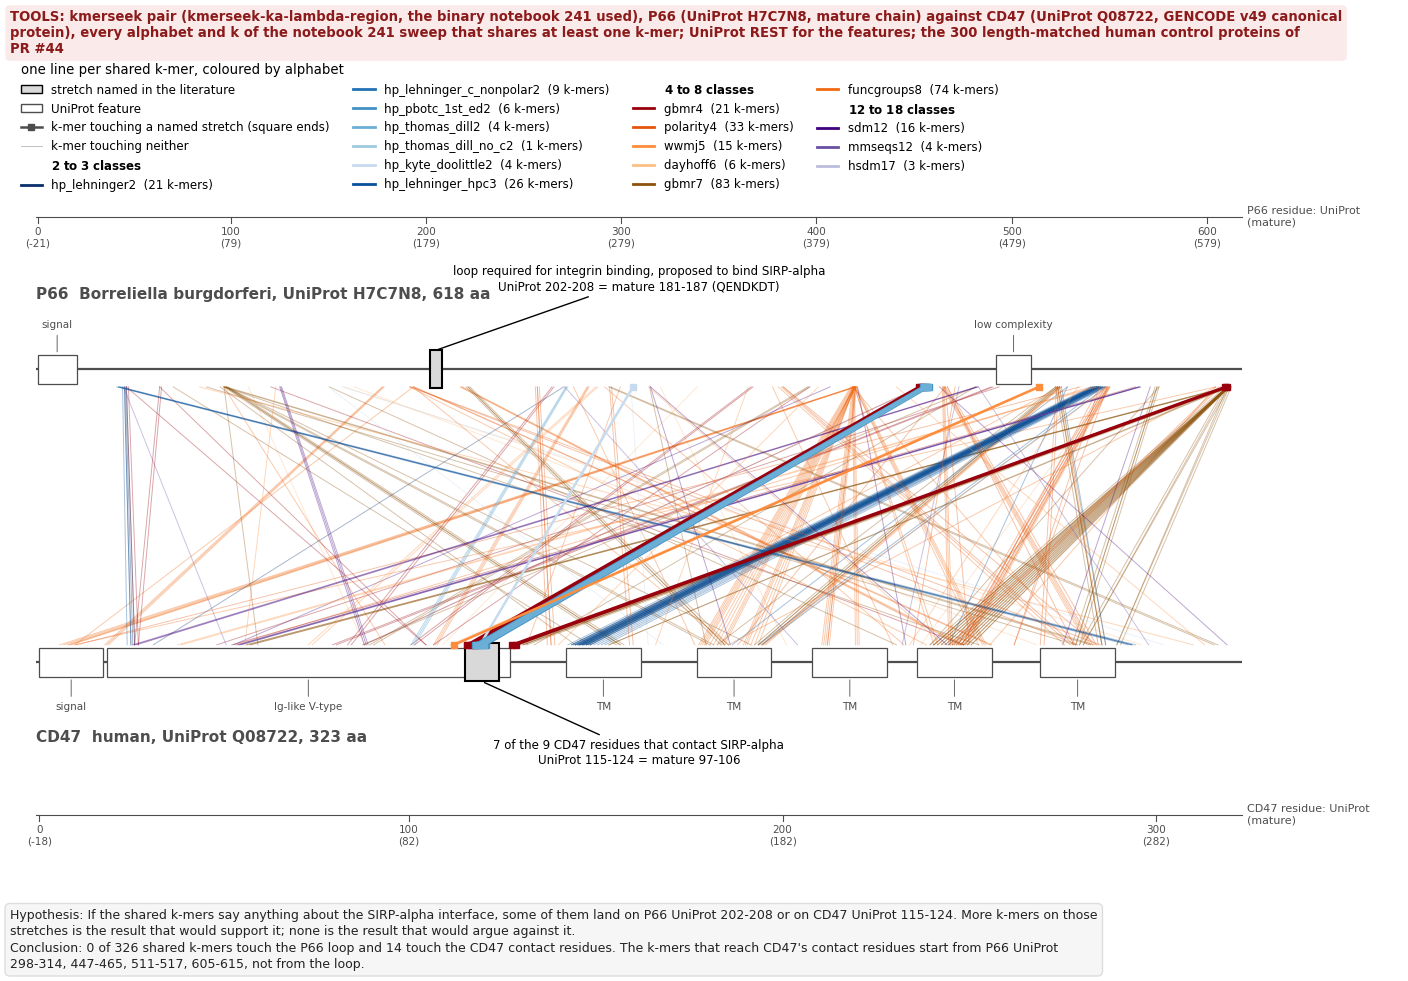

In [3]:
pc.figure_map(
    data, pc.FIG / "245_p66_cd47_shared_kmer_map.png",
    hypothesis=("If the shared k-mers say anything about the SIRP-alpha interface, some of "
                "them land on P66 UniProt 202-208 or on CD47 UniProt 115-124. More k-mers "
                "on those stretches is the result that would support it; none is the result "
                "that would argue against it."),
    conclusion=(f"{touch_loop} of {n_kmers} shared k-mers touch the P66 loop and "
                f"{touch_contact} touch the CD47 contact residues. The k-mers that reach "
                f"CD47's contact residues start from P66 UniProt "
                f"{pc.merged_spans(kmers.filter(pl.col('overlaps_cd47_contact_span')), 'p66_start_uniprot', 'p66_end_uniprot')}, "
                f"not from the loop."),
)
print("figures/245_p66_cd47_shared_kmer_map.png")
print(kmers.filter(pl.col("overlaps_cd47_contact_span"))
      .select("alphabet", "ksize", "p66_start_uniprot", "p66_end_uniprot",
              "p66_start_mature", "p66_end_mature", "cd47_start_uniprot",
              "cd47_end_uniprot", "cd47_start_mature", "cd47_end_mature",
              "n_identical_residues", "n_cd47_contact_residues_covered",
              "cd47_feature_hit"))

## 2. The real residues

For each alphabet, the shared k-mer that covers the most named residues, printed as the two
sequences with a match line, the class letters kmerseek encoded them to, and what each class
letter stands for. kmerseek k-mers are exact matches in the reduced alphabet and carry no
gaps, so these are ungapped and the two spans are the same length.

In [4]:
best = pc.best_per_alphabet(kmers)
for row in best.sort(["n_cd47_contact_residues_covered", "alphabet"],
                     descending=[True, False]).iter_rows(named=True):
    print(pc.residue_block(kmers, row))
    print()

hp_kyte_doolittle2 k=17  (15.9 bits per seed)
  P66   UniProt 298-314 (mature 277-293)  KYKLGLTKINDKNTYLI
                                           |    |         |
  CD47  UniProt 111-127 (mature  93-109)  NYTCEVTELTREGETII
  classes                                 ppphphpphpppppphh
  3 of 17 residues identical; covers 7 of the 7 CD47 contact residues and 0 of the 7 P66 loop residues
  h = ACFILMV; p = DEGKNPQRSTWY

hp_pbotc_1st_ed2 k=16  (15.9 bits per seed)
  P66   UniProt 449-464 (mature 428-443)  LNVEISSYEDNKKGII
                                             |          ||
  CD47  UniProt 112-127 (mature  94-109)  YTCEVTELTREGETII
  classes                                 hphphpphpppppphh
  3 of 16 residues identical; covers 7 of the 7 CD47 contact residues and 0 of the 7 P66 loop residues
  h = ACILMVY; p = DEGHKNQRST

hp_thomas_dill2 k=17  (16.4 bits per seed)
  P66   UniProt 448-464 (mature 427-443)  SLNVEISSYEDNKKGII
                                              |          ||
 

## 3. Control 1: is that more than chance gives

A k-mer of length k can start at any of (protein length - k + 1) places. The share of those
places from which it touches a named stretch is what chance gives. Observed against expected,
per arm, with a binomial test.

The k-mers within one arm are not independent draws: consecutive positions share k-1
residues, and the 14 k-mers that touch CD47's contact residues chain into 6 regions. So the
per-arm tests are optimistic and the pooled test below is read as a direction, not as a
p-value to defend.

In [5]:
from scipy import stats

exp_loop = float(controls["expected_touching_p66_loop"].sum())
exp_contact = float(controls["expected_touching_cd47_contact_span"].sum())
p_pooled_loop = float(stats.binomtest(touch_loop, n_kmers, exp_loop / n_kmers).pvalue)
p_pooled_contact = float(stats.binomtest(touch_contact, n_kmers, exp_contact / n_kmers).pvalue)
print(f"P66 loop:    {touch_loop} observed, {exp_loop:.1f} expected, binomial p = {p_pooled_loop:.5f}")
print(f"CD47 contacts: {touch_contact} observed, {exp_contact:.1f} expected, "
      f"binomial p = {p_pooled_contact:.3f}")

bonferroni = 0.05 / n_arms
sig = controls.filter((pl.col("cd47_contact_binomial_p") < 0.05)
                      | (pl.col("p66_loop_binomial_p") < 0.05))
print(f"\narms with a binomial p below 0.05 on either stretch "
      f"(0.05 / {n_arms} arms = {bonferroni:.5f} after correcting for testing every arm):")
print(sig.select("alphabet", "ksize", "n_shared_kmers",
                 "n_touching_cd47_contact_span", "expected_touching_cd47_contact_span",
                 "cd47_contact_binomial_p", "n_touching_p66_loop",
                 "expected_touching_p66_loop", "p66_loop_binomial_p"))
n_survive = sig.filter(pl.col("cd47_contact_binomial_p") < bonferroni).height
print(f"{n_survive} arm(s) stay below {bonferroni:.5f}")

P66 loop:    0 observed, 8.5 expected, binomial p = 0.00035
CD47 contacts: 14 observed, 19.1 expected, binomial p = 0.287

arms with a binomial p below 0.05 on either stretch (0.05 / 27 arms = 0.00185 after correcting for testing every arm):
shape: (4, 9)
┌──────────────────┬───────┬────────────────┬──────────────────────────────┬───┬─────────────────────────┬─────────────────────┬────────────────────────────┬─────────────────────┐
│ alphabet         ┆ ksize ┆ n_shared_kmers ┆ n_touching_cd47_contact_span ┆ … ┆ cd47_contact_binomial_p ┆ n_touching_p66_loop ┆ expected_touching_p66_loop ┆ p66_loop_binomial_p │
│ ---              ┆ ---   ┆ ---            ┆ ---                          ┆   ┆ ---                     ┆ ---                 ┆ ---                        ┆ ---                 │
│ str              ┆ i64   ┆ i64            ┆ i64                          ┆   ┆ f64                     ┆ i64                 ┆ f64                        ┆ f64                 │
╞══════════════════╪════

## 4. Control 2: does CD47 stand out among 300 human proteins of its length

Each arm run on P66 against the 300 human proteins PR #44 drew, and CD47's shared-k-mer
count placed in that distribution. 50 means an ordinary protein of that length.

In [6]:
med_pct = float(controls["cd47_percentile_among_controls"].median())
n_top = controls.filter(pl.col("cd47_percentile_among_controls") >= 95).height
n_bottom = controls.filter(pl.col("cd47_percentile_among_controls") <= 50).height
print(f"CD47's percentile among the 300 controls: median {med_pct:.0f} over {n_arms} arms; "
      f"{n_top} arms put it at or above 95, {n_bottom} at or below 50")
print(controls.sort("cd47_percentile_among_controls", descending=True)
      .select("alphabet", "ksize", "n_shared_kmers", "control_median_shared_kmers",
              "control_max_shared_kmers", "n_control_ge_cd47",
              "cd47_percentile_among_controls"))

CD47's percentile among the 300 controls: median 84 over 27 arms; 3 arms put it at or above 95, 5 at or below 50
shape: (27, 7)
┌──────────────────────────┬───────┬────────────────┬─────────────────────────────┬──────────────────────────┬───────────────────┬────────────────────────────────┐
│ alphabet                 ┆ ksize ┆ n_shared_kmers ┆ control_median_shared_kmers ┆ control_max_shared_kmers ┆ n_control_ge_cd47 ┆ cd47_percentile_among_controls │
│ ---                      ┆ ---   ┆ ---            ┆ ---                         ┆ ---                      ┆ ---               ┆ ---                            │
│ str                      ┆ i64   ┆ i64            ┆ f64                         ┆ i64                      ┆ i64               ┆ f64                            │
╞══════════════════════════╪═══════╪════════════════╪═════════════════════════════╪══════════════════════════╪═══════════════════╪════════════════════════════════╡
│ funcgroups8              ┆ 6     ┆ 58             

figures/245_p66_cd47_controls.png


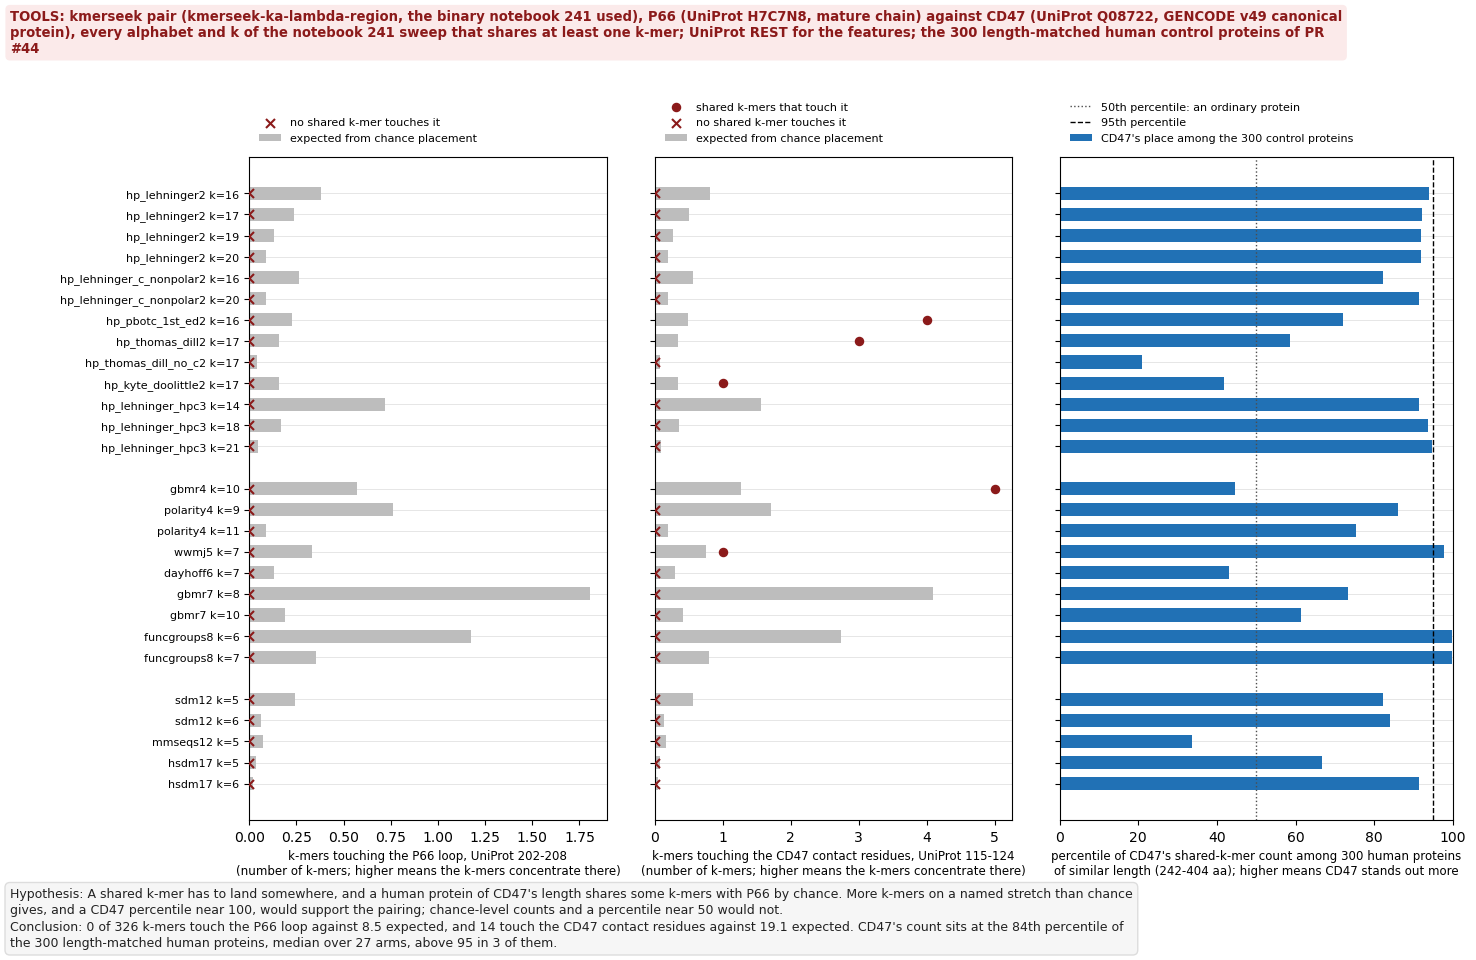

In [7]:
pc.figure_controls(
    data, pc.FIG / "245_p66_cd47_controls.png",
    hypothesis=("A shared k-mer has to land somewhere, and a human protein of CD47's length "
                "shares some k-mers with P66 by chance. More k-mers on a named stretch than "
                "chance gives, and a CD47 percentile near 100, would support the pairing; "
                "chance-level counts and a percentile near 50 would not."),
    conclusion=(f"{touch_loop} of {n_kmers} k-mers touch the P66 loop against "
                f"{exp_loop:.1f} expected, and {touch_contact} touch the CD47 contact "
                f"residues against {exp_contact:.1f} expected. CD47's count sits at the "
                f"{med_pct:.0f}th percentile of the 300 length-matched human proteins, "
                f"median over {n_arms} arms, above 95 in {n_top} of them."),
)
print("figures/245_p66_cd47_controls.png")

## 5. Conclusions

In [8]:
p66_sources = pc.merged_spans(kmers.filter(pl.col("overlaps_cd47_contact_span")),
                              "p66_start_uniprot", "p66_end_uniprot")
loop_word = "None of" if touch_loop == 0 else f"{touch_loop} of"

print(f"1. {loop_word} the {n_kmers} shared k-mers, and {reg_loop} of the {n_regions} "
      f"chained regions, overlap P66 UniProt 202-208 (mature 181-187, QENDKDT), in any "
      f"of the {n_arms} arms.")
print()
print(f"2. {touch_contact} shared k-mers touch CD47 UniProt 115-124, against "
      f"{exp_contact:.1f} expected from chance placement, binomial p = {p_pooled_contact:.2f}. "
      f"For the P66 loop it is {touch_loop} against {exp_loop:.1f} expected, binomial "
      f"p = {p_pooled_loop:.5f}, which is fewer than chance rather than more. "
      f"{all_seven} k-mers cover all seven contact residues, from {arms_touching} arms, "
      f"and they reach them from P66 UniProt {p66_sources}. Three arms put more k-mers on "
      f"the CD47 contact residues than chance at p < 0.05 and {n_survive} stays below "
      f"{bonferroni:.5f}, the threshold after testing every arm.")
print()
top = (controls.filter(pl.col("cd47_percentile_among_controls") >= 95)
       .sort("cd47_percentile_among_controls", descending=True))
top_text = "; ".join(
    f"{r['alphabet']} k={r['ksize']}, CD47 {r['n_shared_kmers']} against a control median "
    f"of {r['control_median_shared_kmers']:.0f} and a control maximum of "
    f"{r['control_max_shared_kmers']}"
    for r in top.iter_rows(named=True))
print(f"3. CD47 sits at the {med_pct:.0f}th percentile of the 300 human proteins of its "
      f"length, median over the {n_arms} arms, at or above 95 in {n_top} arms and at or "
      f"below 50 in {n_bottom}. The {n_top} arms that put it highest: {top_text}.")
print()
print("4. These tables do not show that P66 mimics CD47. They show where the shared k-mers "
      "sit: not on the loop that integrin binding needs, and on CD47's contact residues no "
      "more often than a k-mer landing at random would.")

1. None of the 326 shared k-mers, and 0 of the 213 chained regions, overlap P66 UniProt 202-208 (mature 181-187, QENDKDT), in any of the 27 arms.

2. 14 shared k-mers touch CD47 UniProt 115-124, against 19.1 expected from chance placement, binomial p = 0.29. For the P66 loop it is 0 against 8.5 expected, binomial p = 0.00035, which is fewer than chance rather than more. 8 k-mers cover all seven contact residues, from 5 arms, and they reach them from P66 UniProt 298-314, 447-465, 511-517, 605-615. Three arms put more k-mers on the CD47 contact residues than chance at p < 0.05 and 1 stays below 0.00185, the threshold after testing every arm.

3. CD47 sits at the 84th percentile of the 300 human proteins of its length, median over the 27 arms, at or above 95 in 3 arms and at or below 50 in 5. The 3 arms that put it highest: funcgroups8 k=6, CD47 58 against a control median of 10 and a control maximum of 59; funcgroups8 k=7, CD47 16 against a control median of 2 and a control maximum of 19

Answering the three questions in one sentence each, from the tables above:

* **Does any shared k-mer touch P66 202-208 or CD47 115-124?** None of the 326 touches the
  P66 loop; 14 touch the CD47 contact residues, and they reach them from four other
  parts of P66 (UniProt 298-314, 447-465, 511-517 and 605-615), not from the loop.
* **Is that more than chance gives?** No. 14 against 19.1 expected for CD47's contact
  residues (binomial p = 0.29), and 0 against 8.5 expected for the P66 loop
  (binomial p = 0.00035), which is fewer than chance, not more.
* **Does CD47 stand out among the 300 length-matched human proteins?** No. Its shared-k-mer
  count sits at the 84th percentile, median over the 27 arms, and reaches the 95th in 3 of
  them (funcgroups8 k=6 and k=7, wwmj5 k=7).

Files this notebook reads and writes:

| file | what is in it |
|---|---|
| `tables/245_p66_cd47_annotations.csv` | both sequences and every UniProt feature, plus the published residues, in both numberings |
| `tables/245_p66_cd47_shared_kmers.csv` | one row per shared k-mer |
| `tables/245_p66_cd47_regions.csv` | the chained regions kmerseek reports |
| `tables/245_p66_cd47_controls.csv` | both controls, one row per arm |
| `tables/245_p66_cd47_control_counts.csv` | the shared-k-mer count for each of the 300 control proteins in each arm |
| `figures/245_p66_cd47_shared_kmer_map.png` | section 1 |
| `figures/245_p66_cd47_controls.png` | section 4 |